In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/DataCoSupplyChainDataset.csv', encoding='latin1')

df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [ ]:
# How many rows and columns
print("Shape of dataset:", df.shape)

# List all column names
print("\nColumn names:")
print(df.columns.tolist())

Shape of dataset: (180519, 53)

Column names:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Pric

In [3]:
# Data types and missing values check
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 53 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Email                 180519 non-null  str    
 12  Customer Fname                 180519 non

In [4]:
# Let's look at a random sample of rows to understand the actual values, not just column names
df.sample(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
93352,DEBIT,4,4,161.270004,335.980011,Shipping on time,0,45,Fishing,Marietta,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,4/23/2015 11:45,Standard Class
15650,CASH,2,1,19.740000,40.290001,Late delivery,1,41,Trade-In,Los Angeles,...,NaN,924,41,NaN,http://images.acmesports.sports/Glove+It+Urban...,Glove It Urban Brick Golf Towel,15.990000,0,3/25/2016 5:09,First Class
57946,DEBIT,4,4,20.750000,207.500000,Shipping on time,0,24,Women's Apparel,Caguas,...,NaN,502,24,NaN,http://images.acmesports.sports/Nike+Men%27s+D...,Nike Men's Dri-FIT Victory Golf Polo,50.000000,0,10/21/2016 21:40,Standard Class
164589,DEBIT,3,4,-55.400002,232.759995,Advance shipping,0,17,Cleats,Pomona,...,NaN,365,17,NaN,http://images.acmesports.sports/Perfect+Fitnes...,Perfect Fitness Perfect Rip Deck,59.990002,0,4/28/2015 21:33,Standard Class
47117,PAYMENT,2,4,-86.940002,104.370003,Advance shipping,0,29,Shop By Sport,Martinez,...,NaN,627,29,NaN,http://images.acmesports.sports/Under+Armour+G...,Under Armour Girls' Toddler Spine Surge Runni,39.990002,0,12/5/2016 12:19,Standard Class


In [ ]:
# specifically checking the columns most relevant to the project's business question
columns_of_interest = [
    'Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
    'Delivery Status', 'Late_delivery_risk', 'Category Name',
    'Customer Segment', 'Order Region', 'Order Country',
    'Shipping Mode', 'Order Item Discount Rate', 'Order Item Product Price',
    'Sales per customer', 'Benefit per order'
]

df[columns_of_interest].sample(5)

,Type,Days for shipping (real),Days for shipment (scheduled),Delivery Status,Late_delivery_risk,Category Name,Customer Segment,Order Region,Order Country,Shipping Mode,Order Item Discount Rate,Order Item Product Price,Sales per customer,Benefit per order
14458,DEBIT,4,4,Shipping on time,0,Cardio Equipment,Corporate,Western Europe,Francia,Standard Class,0.25,99.989998,299.970001,86.989998
57363,DEBIT,6,4,Late delivery,1,Shop By Sport,Consumer,Central America,El Salvador,Standard Class,0.04,39.990002,153.559998,13.820000
102535,PAYMENT,2,4,Advance shipping,0,Water Sports,Consumer,South Asia,India,Standard Class,0.15,199.990005,169.990005,61.200001
170932,TRANSFER,3,4,Advance shipping,0,Camping & Hiking,Home Office,South Asia,India,Standard Class,0.06,299.980011,283.480011,70.870003
95144,DEBIT,6,4,Late delivery,1,Men's Footwear,Consumer,West of USA,Estados Unidos,Standard Class,0.05,129.990005,123.489998,55.570000


In [6]:
# Check what values Late_delivery_risk actually contains
print("Late_delivery_risk unique values:", df['Late_delivery_risk'].unique())

# Check what values Order Region actually contains
print("\nOrder Region unique values:")
print(df['Order Region'].unique())

Late_delivery_risk unique values: [0 1]

Order Region unique values:
<ArrowStringArray>
[ 'Southeast Asia',      'South Asia',         'Oceania',    'Eastern Asia',
       'West Asia',    'West of USA ',      'US Center ',     'West Africa',
  'Central Africa',    'North Africa',  'Western Europe', 'Northern Europe',
 'Central America',       'Caribbean',   'South America',     'East Africa',
 'Southern Europe',     'East of USA',          'Canada', 'Southern Africa',
    'Central Asia',  'Eastern Europe',  'South of  USA ']
Length: 23, dtype: str


In [7]:
# Drop columns that are personal/sensitive info or not useful for prediction
columns_to_drop = [
    'Customer Email', 'Customer Password', 'Customer Fname', 'Customer Lname',
    'Customer Street', 'Customer Zipcode', 'Product Description', 'Product Image',
    'Order Zipcode', 'Order Status', 'Order Customer Id', 'Order Id',
    'Order Item Id', 'Order Item Cardprod Id', 'Product Card Id', 'Product Category Id'
]

# errors='ignore' means: if a column name doesn't exist in df, don't crash - just skip it
df_clean = df.drop(columns=columns_to_drop, errors='ignore')

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (180519, 53)
Cleaned shape: (180519, 37)


Shipping Mode
First Class       95.322499
Second Class      76.632781
Same Day          45.743042
Standard Class    38.071683
Name: Late_delivery_risk, dtype: float64


C:\Users\USER\AppData\Local\Temp\ipykernel_23776\1637796989.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=late_by_mode.values, y=late_by_mode.index, palette='Reds_r')


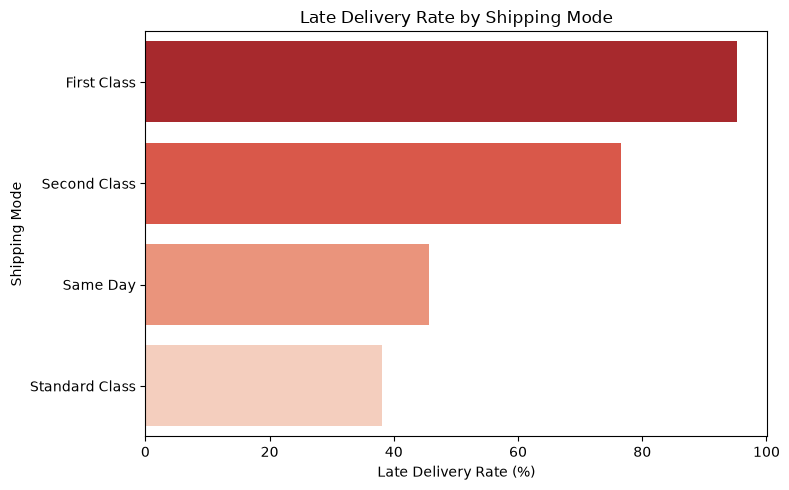

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the late delivery rate (%) for each shipping mode
late_by_mode = df_clean.groupby('Shipping Mode')['Late_delivery_risk'].mean().sort_values(ascending=False) * 100

print(late_by_mode)

# Plot it as a bar chart
plt.figure(figsize=(8,5))
sns.barplot(x=late_by_mode.values, y=late_by_mode.index, palette='Reds_r')
plt.xlabel('Late Delivery Rate (%)')
plt.title('Late Delivery Rate by Shipping Mode')
plt.tight_layout()
plt.show()

In [9]:
# Compare average scheduled days vs actual days, by shipping mode
shipping_comparison = df_clean.groupby('Shipping Mode')[['Days for shipment (scheduled)', 'Days for shipping (real)']].mean()

shipping_comparison['Avg Delay (days)'] = shipping_comparison['Days for shipping (real)'] - shipping_comparison['Days for shipment (scheduled)']

print(shipping_comparison.sort_values('Avg Delay (days)', ascending=False))

                Days for shipment (scheduled)  Days for shipping (real)  \
Shipping Mode                                                             
Second Class                              2.0                  3.990828   
First Class                               1.0                  2.000000   
Same Day                                  0.0                  0.478279   
Standard Class                            4.0                  3.995907   

                Avg Delay (days)  
Shipping Mode                     
Second Class            1.990828  
First Class             1.000000  
Same Day                0.478279  
Standard Class         -0.004093  


In [10]:
# Late delivery rate by region, sorted worst to best
late_by_region = df_clean.groupby('Order Region')['Late_delivery_risk'].mean().sort_values(ascending=False) * 100

print(late_by_region)

Order Region
Central Africa     57.960644
South Asia         56.266977
East Africa        55.939525
Western Europe     55.848611
South of  USA      55.772559
Eastern Europe     55.663265
East of USA        55.661605
Southeast Asia     55.529930
Central Asia       55.334539
West Asia          55.283741
US Center          55.240360
Central America    54.754596
North Africa       54.517327
Southern Europe    54.384477
Eastern Asia       54.326923
South America      54.308671
Northern Europe    54.044118
Oceania            54.020497
West of USA        53.959715
Southern Africa    53.327571
Caribbean          53.077663
West Africa        52.840909
Canada             48.800834
Name: Late_delivery_risk, dtype: float64


In [ ]:
# Save cleaned dataset so it can be reused without re-cleaning every time
df_clean.to_csv('../data/cleaned_supply_chain.csv', index=False)
print("Saved cleaned_supply_chain.csv successfully!")

Saved cleaned_supply_chain.csv successfully!


In [ ]:
# Start fresh from the cleaned data 
df_feat = df_clean.copy()

# Feature 1: Scheduling Gap - how many days "behind" the promise was this order, on average for its shipping mode
df_feat['Scheduling_Gap'] = df_feat['Days for shipping (real)'] - df_feat['Days for shipment (scheduled)']

# Feature 2: Is this order in West Asia? 1 = yes, 0 = no
df_feat['Is_West_Asia'] = (df_feat['Order Region'] == 'West Asia').astype(int)

# Feature 3: Discount level bucket - sometimes heavily discounted orders get deprioritized in fulfillment
df_feat['High_Discount'] = (df_feat['Order Item Discount Rate'] > 0.15).astype(int)

# Quick check
df_feat[['Scheduling_Gap', 'Is_West_Asia', 'High_Discount']].head()

,Scheduling_Gap,Is_West_Asia,High_Discount
0,-1,0,0
1,1,0,0
2,0,0,0
3,-1,0,0
4,-2,0,0


In [ ]:
#check what the date column actually looks like right now
print(df_feat['order date (DateOrders)'].head())
print("\nCurrent data type:", df_feat['order date (DateOrders)'].dtype)

0    1/31/2018 22:56
1    1/13/2018 12:27
2    1/13/2018 12:06
3    1/13/2018 11:45
4    1/13/2018 11:24
Name: order date (DateOrders), dtype: str

Current data type: str


In [ ]:
# Convert the text date into an actual datetime object so pandas can understand
df_feat['order date (DateOrders)'] = pd.to_datetime(df_feat['order date (DateOrders)'], format='%m/%d/%Y %H:%M')

#extract useful time-based features from it
df_feat['Order_Month'] = df_feat['order date (DateOrders)'].dt.month
df_feat['Order_DayOfWeek'] = df_feat['order date (DateOrders)'].dt.dayofweek  # Monday=0, Sunday=6
df_feat['Order_IsWeekend'] = (df_feat['Order_DayOfWeek'] >= 5).astype(int)  # Saturday/Sunday = 1

# Quick check
df_feat[['order date (DateOrders)', 'Order_Month', 'Order_DayOfWeek', 'Order_IsWeekend']].head()

,order date (DateOrders),Order_Month,Order_DayOfWeek,Order_IsWeekend
0,2018-01-31 22:56:00,1,2,0
1,2018-01-13 12:27:00,1,5,1
2,2018-01-13 12:06:00,1,5,1
3,2018-01-13 11:45:00,1,5,1
4,2018-01-13 11:24:00,1,5,1


In [15]:
# Late delivery rate: weekend orders vs weekday orders
weekend_effect = df_feat.groupby('Order_IsWeekend')['Late_delivery_risk'].mean() * 100
print("Late delivery rate by weekend flag (0=Weekday, 1=Weekend):")
print(weekend_effect)

# Late delivery rate by month
month_effect = df_feat.groupby('Order_Month')['Late_delivery_risk'].mean() * 100
print("\nLate delivery rate by month:")
print(month_effect)

Late delivery rate by weekend flag (0=Weekday, 1=Weekend):
Order_IsWeekend
0    54.858866
1    54.755338
Name: Late_delivery_risk, dtype: float64

Late delivery rate by month:
Order_Month
1     54.658212
2     54.552963
3     55.254727
4     54.279236
5     54.738358
6     54.825286
7     54.057279
8     55.794369
9     55.297308
10    54.596681
11    54.552000
12    55.335318
Name: Late_delivery_risk, dtype: float64


In [ ]:
# Select the columns actually feed into the model
model_columns = [
    'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer',
    'Category Name', 'Customer Segment', 'Order Region', 'Shipping Mode',
    'Order Item Discount Rate', 'Order Item Product Price',
    'Scheduling_Gap', 'Is_West_Asia', 'High_Discount',
    'Order_Month', 'Order_DayOfWeek', 'Order_IsWeekend',
    'Late_delivery_risk'  # this is our target - what we're trying to predict
]

df_model = df_feat[model_columns].copy()

print(df_model.shape)
df_model.head()

(180519, 16)


,Days for shipment (scheduled),Benefit per order,Sales per customer,Category Name,Customer Segment,Order Region,Shipping Mode,Order Item Discount Rate,Order Item Product Price,Scheduling_Gap,Is_West_Asia,High_Discount,Order_Month,Order_DayOfWeek,Order_IsWeekend,Late_delivery_risk
0,4,91.250000,314.640015,Sporting Goods,Consumer,Southeast Asia,Standard Class,0.04,327.75,-1,0,0,1,2,0,0
1,4,-249.089996,311.359985,Sporting Goods,Consumer,South Asia,Standard Class,0.05,327.75,1,0,0,1,5,1,1
2,4,-247.779999,309.720001,Sporting Goods,Consumer,South Asia,Standard Class,0.06,327.75,0,0,0,1,5,1,0
3,4,22.860001,304.809998,Sporting Goods,Home Office,Oceania,Standard Class,0.07,327.75,-1,0,0,1,5,1,0
4,4,134.210007,298.250000,Sporting Goods,Corporate,Oceania,Standard Class,0.09,327.75,-2,0,0,1,5,1,0


In [ ]:
# Identify which columns are still text (categorical)
categorical_cols = ['Category Name', 'Customer Segment', 'Order Region', 'Shipping Mode']

# One-hot encode
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print("Shape before encoding:", df_model.shape)
print("Shape after encoding:", df_encoded.shape)

Shape before encoding: (180519, 16)
Shape after encoding: (180519, 88)


In [ ]:
from sklearn.model_selection import train_test_split

# Separate features (X) from target (y)
X = df_encoded.drop('Late_delivery_risk', axis=1)
y = df_encoded['Late_delivery_risk']

# Split into 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nLate delivery rate in training set:", y_train.mean())
print("Late delivery rate in testing set:", y_test.mean())

Training set size: (144415, 87)
Testing set size: (36104, 87)

Late delivery rate in training set: 0.548287920229893
Late delivery rate in testing set: 0.5483048969643253


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, classification_report

# Create the model
model = RandomForestClassifier(
    n_estimators=100,      # how many individual trees to build
    max_depth=10,          # how deep each tree can grow (limits overfitting)
    random_state=42,       # reproducibility, same idea as before
    n_jobs=-1               # use all CPU cores available to train faster
)

# Train it on the training data
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [20]:
# Get predictions on the test set
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # probability of being late (class 1)

# Calculate key metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")

print("\nFull classification report:")
print(classification_report(y_test, y_pred))

Accuracy:  0.974
Precision: 0.955
Recall:    1.000
ROC-AUC:   0.973

Full classification report:
              precision    recall  f1-score   support

           0       1.00      0.94      0.97     16308
           1       0.96      1.00      0.98     19796

    accuracy                           0.97     36104
   macro avg       0.98      0.97      0.97     36104
weighted avg       0.98      0.97      0.97     36104



In [ ]:
# Remove the leaky feature and rebuild the feature set properly
X_train_fixed = X_train.drop(columns=['Scheduling_Gap'])
X_test_fixed = X_test.drop(columns=['Scheduling_Gap'])

# Retrain the model without the leaky feature
model_fixed = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

model_fixed.fit(X_train_fixed, y_train)

# Re-evaluate honestly
y_pred_fixed = model_fixed.predict(X_test_fixed)
y_pred_proba_fixed = model_fixed.predict_proba(X_test_fixed)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred_fixed):.3f}")
print(f"Precision: {precision_score(y_test, y_pred_fixed):.3f}")
print(f"Recall:    {recall_score(y_test, y_pred_fixed):.3f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_pred_proba_fixed):.3f}")

Accuracy:  0.694
Precision: 0.805
Recall:    0.584
ROC-AUC:   0.734


Days for shipment (scheduled)    0.437460
Shipping Mode_Standard Class     0.371928
Shipping Mode_Second Class       0.075791
Shipping Mode_Same Day           0.060788
Benefit per order                0.009090
Sales per customer               0.006890
Order Item Discount Rate         0.005117
Order_DayOfWeek                  0.004769
Order_Month                      0.004667
Order Item Product Price         0.002457
Customer Segment_Corporate       0.001568
Customer Segment_Home Office     0.001381
Order_IsWeekend                  0.001314
High_Discount                    0.000931
Order Region_Oceania             0.000632
dtype: float64


C:\Users\USER\AppData\Local\Temp\ipykernel_23776\1302946324.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='Blues_r')


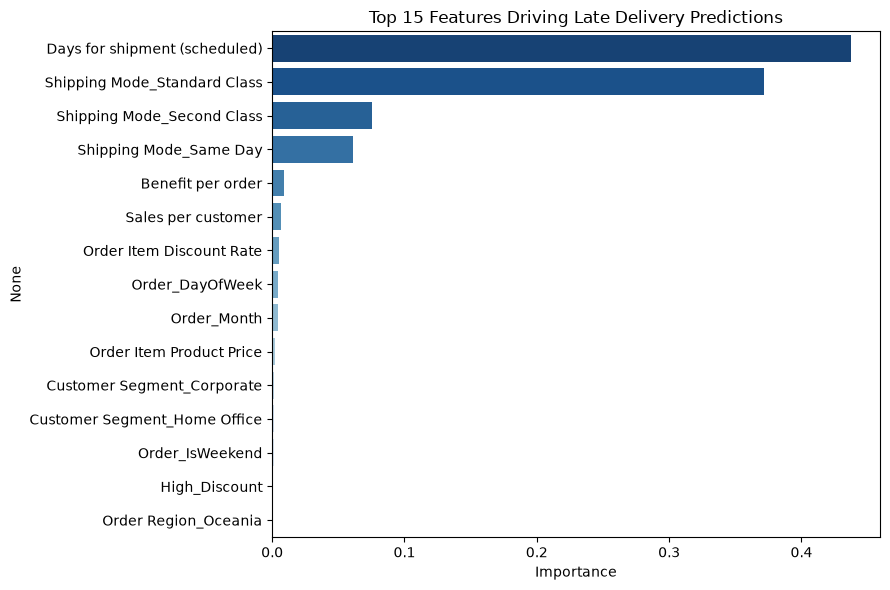

In [22]:
# Get feature importance from the model
importances = pd.Series(model_fixed.feature_importances_, index=X_train_fixed.columns)
top_features = importances.sort_values(ascending=False).head(15)

print(top_features)

# Plot it
plt.figure(figsize=(9,6))
sns.barplot(x=top_features.values, y=top_features.index, palette='Blues_r')
plt.xlabel('Importance')
plt.title('Top 15 Features Driving Late Delivery Predictions')
plt.tight_layout()
plt.show()

In [ ]:
import shap

# Create the SHAP explainer for the model
explainer = shap.TreeExplainer(model_fixed)

# Calculate SHAP values for a sample of the test set
X_sample = X_test_fixed.sample(500, random_state=42)
shap_values = explainer.shap_values(X_sample)

print("SHAP values calculated successfully!")
print("Shape:", shap_values.shape if hasattr(shap_values, 'shape') else len(shap_values))

SHAP values calculated successfully!
Shape: (500, 86, 2)


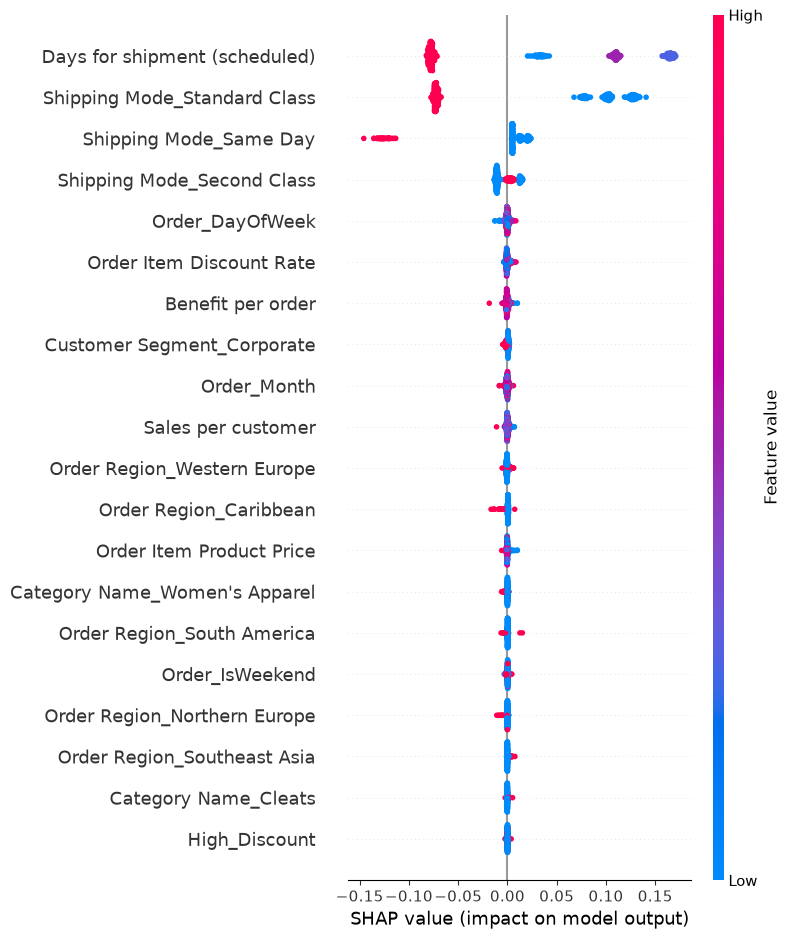

In [24]:
# Select SHAP values for class 1 (late delivery) specifically
shap_values_late = shap_values[:, :, 1]

# Create the summary plot - shows which features matter most AND how they push predictions
shap.summary_plot(shap_values_late, X_sample, show=False)
plt.tight_layout()
plt.savefig('../notebooks/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import joblib

# Save the trained model to a file
joblib.dump(model_fixed, '../app/late_delivery_model.pkl')

# Also save the exact column structure the model expects
joblib.dump(X_train_fixed.columns.tolist(), '../app/model_columns.pkl')

print("Model and column list saved successfully!")

Model and column list saved successfully!
